# Revision: Scene setting
- Global scene setting: Same to CuRobo, Moveit, etc.

#### 1. Initialize environment

In [1]:
from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.qt import *
# trajectory tools 
from ri_motion_v5_package.traj_optimization.traj_utils import *
from ri_motion_v5_package.traj_optimization.traj_shaper import *
# gp tools 
from ri_motion_v5_package.gaussian_process.gp_utils import *
from ri_motion_v5_package.gaussian_process.kernels import rbf_kernel

from package.panda_env import * 

from PyQt5.QtWidgets import QApplication
app = QApplication(sys.argv)

from package.nfg import *

Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.
Ready.


In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files = [
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/cabinet/cabinet_half_closed_tall.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_cabinet_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [4] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/cabinet/cabinet_half_closed_tall.xml]
  - [3] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_cabinet_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[28]
 [0/28] [world] parent:[world] mass:[0.00]kg
 [1/28] [panda_base] parent:[world] mass:[0.00]kg
 [2/28] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/28] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/28] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/28] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/28] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/28] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/28] [panda_link_6] parent:[panda_link_5] mass:[

#### 2. Intialize environment and generate smooth trajectory

In [3]:
# Configurations
panda_joints          = get_panda_joint_names() # check
inspire_joints        = get_inspire_joint_names() # check
inspire_active_joints = env.get_active_among_joints(inspire_joints)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
qactive_inspire0      = get_qactive_inspire() # check
q_inspire0            = get_q_inspire(env) # check
q_pandas              = get_q_pandas_cabinet() # check

In [4]:
""" TRAJECTORY 1"""
n_traj = 100
n_iter = 15
topk                = 5
trim_scale          = True
variance            = 1.0
length_scale_coef   = 0.5
contact_gain        = 10.0
motion_gain         = 5.0
q_min               = env.get_joint_mins(panda_joints)
q_max               = env.get_joint_maxs(panda_joints)
seed                = 3
# seed 1, 2 success among 0~4 (40%)
# seed 1, 2, 5, 6 success among 0~9 (40%)

In [5]:
""" TRAJECTORY 1"""
# set panda env 
width,height,x_offset,y_offset = 0.8,0.8,0.1,0.15
set_panda_cabinet_env(
    env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0,
    width,height,x_offset,y_offset, initialize_viewer=False,
    cabinet_name = 'body_cabinet_half_closed_tall',
)

# set anchors and get smoothed trajectory 
anchors = np.vstack((q_pandas['init'],q_pandas['final']))
L, times, traj_smt = get_smooth_traj_from_anchors(
    anchors = anchors,
    freq = 100,
    time = 5.0,
)
traj_update = traj_smt.copy()
# Get covariance matrix
K_chol, t_out = get_covariance_matrix_time_hilbert_space(
    times = times,
    L = L,
    length_scale_coef = length_scale_coef,
    variance = variance,
    kernel = rbf_kernel,
)
# loop: calculate costs, update traj, repeat
for iter_idx in range(n_iter):
    epsilon, traj_multidim = sample_epsilon_squash_trajs_multidim(
        traj=traj_update,
        K_chol=K_chol,
        n_traj=n_traj,
        dim=len(panda_joints),
        q_min=q_min,
        q_max=q_max,
        use_uniform=True,
        seed=seed, # different seed each iteration for more diverse sampling
        squash_margin=0.1,
    )
    # calculate scores
    motion_scores = calculate_motion_score(traj_multidim)
    contact_scores = np.zeros(n_traj)
    for traj_idx in range(n_traj):
        traj = traj_multidim[:,traj_idx,:]
        score_traj_single = np.zeros(L)
        for time_idx in range(L):
            env.forward(q=traj[time_idx], joint_names=panda_joints)
            # ========================================================
            T_palm = get_T_palm_panda_inspire(env)
            T_cylinder = view_in_world(T=p2t(p_cylinder_offset0),T_wl=T_palm)
            env.set_T('body_cylinder','base_body',T_cylinder)
            # ========================================================
            contact_info = env.get_contact_info()
            body_idxs = env.get_body_idxs_from_root_body_name('panda_link_1')
            # contact_info = filter_contact_info_with_body_idxs(contact_info, body_idxs=body_idxs)
            score_current_t = calculate_contact_score(contact_info)
            score_traj_single[time_idx] = score_current_t
        contact_scores[traj_idx] = score_traj_single.min()
    # if solved, terminalize
    if np.any(contact_scores  == 0.0):
        print_green(f"\n Contact-free trajectory found at iteration {iter_idx}, terminalizing optimization.")
        solved_idxs = np.where(contact_scores == 0.0)[0]
        best_solved_idx = solved_idxs[np.argmin(motion_scores[solved_idxs])]
        traj_update = traj_multidim[:,best_solved_idx,:]
        break
    # calculate gradient and update trajectory
    scores = contact_gain * contact_scores - motion_gain * motion_scores
    traj_update, gradient_fixed = update_traj_with_calculated_gradient(
        traj=traj_update,
        scores = scores,
        epsilon=epsilon,
        step_size=0.5,
    )
    print_yellow(f"Iteration {iter_idx+1}/{n_iter}, score_sum: {scores.sum():.4f}, score_max: {scores.max():.4f}, score_min: {scores.min():.4f}")
    seed += 1
traj_best = traj_update

[NFG] Generated smooth trajectory from anchors.
[NFG] Generated covariance matrix for Hilbert space projection.
[NFG] Sampled and squashed trajectories.
[NFG] Updated trajectory with calculated gradient.
Iteration 1/15, score_sum: -3306.8006, score_max: -13.5693, score_min: -156.1815
[NFG] Sampled and squashed trajectories.
[NFG] Updated trajectory with calculated gradient.
Iteration 2/15, score_sum: -2887.5980, score_max: -12.1687, score_min: -206.0991
[NFG] Sampled and squashed trajectories.
[NFG] Updated trajectory with calculated gradient.
Iteration 3/15, score_sum: -3312.0097, score_max: -9.8178, score_min: -153.1611
[NFG] Sampled and squashed trajectories.
[NFG] Updated trajectory with calculated gradient.
Iteration 4/15, score_sum: -2756.9925, score_max: -5.2435, score_min: -80.5913
[NFG] Sampled and squashed trajectories.

 Contact-free trajectory found at iteration 4, terminalizing optimization.


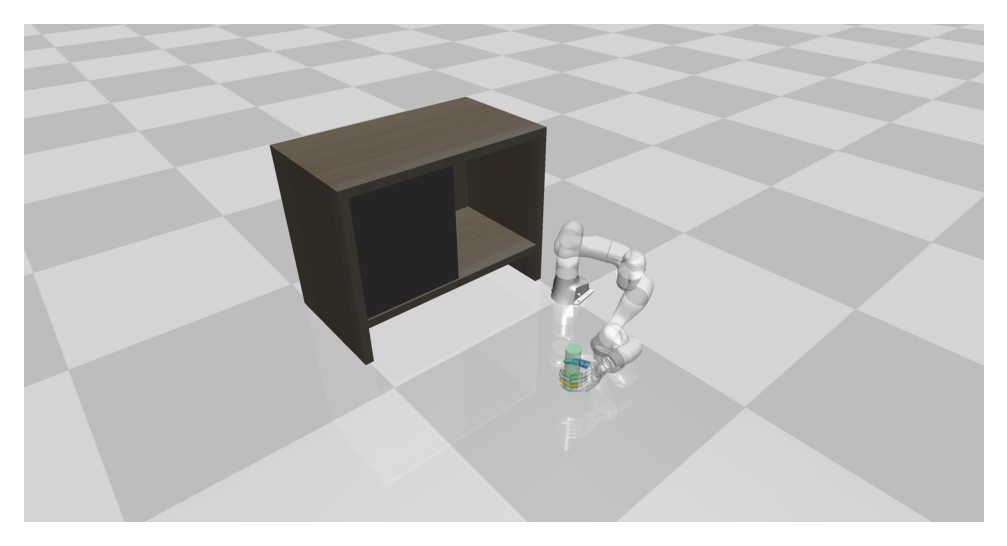

Done.


In [6]:
# animate 
animate_cabinet_env_traj(
    env                = env,
    mode_str           = "NFG_single_step",
    traj               = traj_best,
    panda_joints       = panda_joints,
    inspire_joints     = inspire_joints,
    q_pandas           = q_pandas,
    q_inspire0         = q_inspire0,
    p_cylinder_offset0 = p_cylinder_offset0,
    ubuntu_process_events_flag = True,
    app=app,
    cabinet_name = 'body_cabinet_half_closed_tall',
)
imshow(env.final_rgb_img)
print ("Done.")

In [7]:
def solve_nfg(
        nfg_env,
        robot_name,
        joints_use, 
        anchors, 
        n_traj                   = 20, 
        n_iter                   = 3,
        freq                     = 100,
        time                     = 5.0,
        length_scale_coef        = 0.5,
        variance                 = 0.3,
        kernel                   = rbf_kernel,
        contact_gain             = 10.0,
        motion_gain              = 5.0,
        topk                     = 5,
        trim_scale               = True,
        use_uniform              = True,
        seed                     = 42,
        squash_margin            = 0.1,
        attach_obj_name         = None
):
    """ 
    Generate Collision-free Trajectory using NFG.
    Args:
        - nfg_env: The NFG environment.
        - anchors: The anchor points for the trajectory.
        - freq: The frequency of the trajectory.
        - time: The duration of the trajectory.
        - length_scale_coef: The length scale coefficient for the NFG.
        - variance: The variance for the NFG.
        - kernel: The kernel type for the NFG.
        - contact_gain: The contact gain for the NFG.
    """
    # get joint min/max value 
    q_min = nfg_env.get_joint_mins(joints_use)
    q_max = nfg_env.get_joint_maxs(joints_use)
    # get body idxs for contact filtering
    body_idxs = env.get_body_idxs_from_root_body_name(robot_name)
    # get attach object transform 
    if attach_obj_name is not None:
        T_palm = env.get_T(type="site", name='rpalm')
        T_obj = env.get_T(type="body", name=attach_obj_name)
        T_palm_to_obj = np.linalg.inv(T_palm) @ T_obj
        body_idxs += env.get_body_idxs_from_root_body_name(attach_obj_name)

    L, times, traj_smt = get_smooth_traj_from_anchors(
        anchors = anchors,
        freq = freq,
        time = time,
    )
    traj_update = traj_smt.copy()
    K_chol, t_out = get_covariance_matrix_time_hilbert_space(
        times = times,
        L = L,
        length_scale_coef = length_scale_coef,
        variance = variance,
        kernel = kernel,
    )
    for iter_idx in range(n_iter):
        epsilon, traj_multidim = sample_epsilon_squash_trajs_multidim(
            traj=traj_update,
            K_chol=K_chol,
            n_traj=n_traj,
            dim=len(joints_use),
            q_min=q_min,
            q_max=q_max,
            use_uniform=use_uniform,
            seed=seed,
            squash_margin=squash_margin,
        )
        # calculate scores
        motion_scores = calculate_motion_score(traj_multidim)
        contact_scores = np.zeros(n_traj)
        for traj_idx in range(n_traj):
            traj = traj_multidim[:,traj_idx,:]
            score_traj_single = np.zeros(L)
            for time_idx in range(L):
                env.forward(q=traj[time_idx], joint_names=doosan_joints)
                if attach_obj_name is not None:
                    T_palm = env.get_T(type="site", name='rpalm')
                    T_obj = T_palm @ T_palm_to_obj
                    env.set_T(type="base_body", name=attach_obj_name, T=T_obj)
                contact_info = env.get_contact_info()
                contact_info = filter_contact_info_with_body_idxs(contact_info, body_idxs=body_idxs)
                score_current_t = calculate_contact_score(contact_info)
                score_traj_single[time_idx] = score_current_t
            contact_scores[traj_idx] = score_traj_single.min()
        # if solved, terminalize
        if np.any(contact_scores  == 0.0):
            print_green(f"\n Contact-free trajectory found at iteration {iter_idx}, terminalizing.")
            solved_idxs = np.where(contact_scores == 0.0)[0]
            best_solved_idx = solved_idxs[np.argmin(motion_scores[solved_idxs])]
            traj_update = traj_multidim[:,best_solved_idx,:]
            break
        # calculate gradient and update trajectory
        scores = contact_gain * contact_scores - motion_gain * motion_scores
        traj_update, gradient = update_traj_with_calculated_gradient(
            traj=traj_update,
            scores = scores,
            epsilon=epsilon,
            step_size=0.5,
        )
        print(f"Iteration {iter_idx+1}/{n_iter}, score_sum: {scores.sum():.4f}, score_max: {scores.max():.4f}, score_min: {scores.min():.4f}", end="")
    return traj_update 